In [8]:
from netCDF4 import Dataset as NetCDFFile 
import matplotlib.pyplot as plt
import numpy as np
import geopandas
import rasterio
from mpl_toolkits.basemap import Basemap

import rioxarray
import xarray
import fiona
from fiona import transform
from rasterio.plot import show

import glob, os

from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.patches as patches


from PIL import Image
import matplotlib

import geopandas as gpd
from geocube.api.core import make_geocube
from geocube.rasterize import rasterize_points_griddata

import pyproj

from rasterio.enums import Resampling
from rasterio.windows import from_bounds

import pandas as pd
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.metrics import f1_score, cohen_kappa_score


import shapefile as shp  # Requires the pyshp package


In [110]:
def chla_NIR_rat(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666'):
    '''
    just use NIR ratio 708/666 with no coefficients
    '''
    ratio = df[Rrs_708] / df[Rrs_666]
    return ratio

def chla_NDCI(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666'):
    '''
    use NCDI NIR ratio (708-666)/(708+666)
    '''
    ratio = (df[Rrs_708] - df[Rrs_666]) / (df[Rrs_708] + df[Rrs_666])
    return ratio

def chla_OC4(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.3255, b=-2.7677,
             c=2.4409, d=-1.1288, e=-0.4990, returnX=False):
    '''4 band NASA alg (model L in claire neil paper)'''
    X = np.log10(np.array(np.max([df[Rrs_444], df[Rrs_492], df[Rrs_533]], axis=0)/df[Rrs_566], dtype=float))
    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))

def chla_OC4_mod(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.3255, b=-2.7677,
             c=2.4409, d=-1.1288, e=-0.4990, returnX=False):
    '''4 band NASA alg (model L in claire neil paper)
    with Rrs_444 removed as we cant trust this one... '''
    X = np.log10(np.array(np.max([df[Rrs_492], df[Rrs_533]], axis=0)/df[Rrs_566], dtype=float))
    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))
    
def chla_OC3(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.2424, b=-2.2146,
             c=1.5193, d=-0.7702,
             e=-0.4291, returnX=False):
    '''3 band NASA alg (model M in claire neil paper)'''

    X = np.log10(np.array(np.max([df[Rrs_444],
                                  df[Rrs_492]],
                                 axis=0)/(df[Rrs_566]), dtype=float))

    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))
                
def chla_OC2(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.2389, b=-1.9369,
             c=1.7627, d=-3.0777,
             e=-0.1054, returnX=False):
    '''2 band NASA alg (model N in claire neil paper)'''
    X = np.log10(np.array(df[Rrs_492]/df[Rrs_566], dtype=float))
    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))
    
def chla_RBD(df, Rrs_708='rhos_707', Rrs_666='rhos_666'):
    '''
    NIR/red band difference
    '''
    return df[Rrs_708] - df[Rrs_666]

def chla_RBR3(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666', Rrs_866='Rrs_866'):
    return (df[Rrs_666]**-1 - df[Rrs_708]**-1) * df[Rrs_866]

In [3]:
# store coeffs in dicts

# SuperDoves:

SD_OC3_ac_coeff = {'e':-446.86151603, 'd': -201.59773025,
                   'c':-4.79645411, 'b': 1.20820977, 'a':0.71501882}

# SD_OC3_ac_lin_coeff = {'b':-2.63150769, 'a':0.76734456}

SD_OC3_ac_lin_coeff = {'b':-2.91864966, 'a':0.65474659}

# Sentinel 2:

# S2 c2rcc_CX:

S2_NDCI_c2cx_coeff = {'b':1.67431552, 'a':0.98119468}

S2_OC3_c2cx_lin_coeff = {'b':-1.24879141, 'a':1.04810289}

# S2 acolite:

S2_RBD_ac_coeff = {'b':100.51293461, 'a':0.68839788}

S2_OC3_lin_ac_coeff = {'b':-1.47736103, 'a':0.77251676}


# higher order OC algs - probably not sensible to use as these might be overfitted

S2_OC3_ac_coeff = {'e':-11.85424152, 'd':11.8345101, 'c':8.57455128,
                   'b':-2.22693676,'a':0.32504707}
S2_OC3_c2cx_coeff = {'e':52.21170505, 'd':-11.29312089,
                     'c':-14.27693158, 'b':-1.9865777, 'a':1.27518218}

In [108]:
# I think I might actually only use the best 2 of these
# OC3 and RBD were best!

# s2a: [443., 492., 560., 665., 704., 740., 783., 833., 865.])
# s2b: [442., 492., 559., 665., 704., 739., 780., 833., 864.]

def OC2_tuned_SD(df):
    return chla_OC2(df, 
                    a=0.66076503, b=5.08547344, c=94.24865753,
                    d=392.15536774, e=506.06892637)

def OC2_tuned_S2(df, sensor='S2A'):
    if sensor == 'S2A':
        Rrs_444 = 'Rrs_443'
        Rrs_566 = 'Rrs_560'
    if sensor == 'S2B':
        Rrs_444 = 'Rrs_442'
        Rrs_566 = 'Rrs_559'
    return chla_OC2(df, Rrs_444=Rrs_444, Rrs_492='Rrs_492',
                    Rrs_566=Rrs_566,
                    e=-236.21822107, d=-223.27846193, 
                    c=-60.43881125, b=-5.14908542, a=0.85427622)


def OC3_tuned_SD(df, filetype='l2w', e=-46.25366116, d=-12.96638103, c=7.29677618,
                        b=-0.97394641, a=0.65452869):
    # 
    if filetype == 'l2w':
        return chla_OC3(df,
                        e=e, d=d,
                        c=c, b=b, a=a,)
    elif filetype == 'l2r':
        return chla_OC3(df, Rrs_444='rhos_444', Rrs_492='rhos_492',
                         Rrs_533='rhos_533', Rrs_566='rhos_566',
                        e=e, d=d,
                        c=c, b=b, a=a,
                       )
    
def OC3_linear_SD(df, filetype='l2r', b=-2.63150769, a=0.76734456):
    if filetype == 'l2w':
        X = chla_OC3(df,
                        returnX=True)
    elif filetype == 'l2r':
        X = chla_OC3(df, Rrs_444='rhos_444', Rrs_492='rhos_492',
                         Rrs_533='rhos_533', Rrs_566='rhos_566',
                        returnX=True
                       )
    return 10**(b*X + a)


def OC3_linear_S2(df, sensor='S2A', filetype='acolite',
                    b=0.61589994, a=0.83770047):
    if filetype == 'acolite':
        Rrs_492='Rrs_492'
        if sensor == 'S2A':
            Rrs_444 = 'Rrs_443'
            Rrs_566 = 'Rrs_560'
        if sensor == 'S2B':
            Rrs_444 = 'Rrs_442'
            Rrs_566 = 'Rrs_559'
    elif filetype == 'c2rcc':
        Rrs_444 = 'rrs_B1'
        Rrs_566 = 'rrs_B3'
        Rrs_492 = 'rrs_B2'
    X = chla_OC3(df, Rrs_444=Rrs_444,
                 Rrs_492=Rrs_492, Rrs_566=Rrs_566,
                 returnX=True)
    return 10**(b*X + a)
    
def OC3_tuned_S2(df, sensor='S2A', filetype='acolite',
                 e=-46.52945764, d=-23.12084579, c=3.57432539,
                    b=0.61589994, a=0.83770047):
    if filetype == 'acolite':
        Rrs_492='Rrs_492'
        if sensor == 'S2A':
            Rrs_444 = 'Rrs_443'
            Rrs_566 = 'Rrs_560'
        if sensor == 'S2B':
            Rrs_444 = 'Rrs_442'
            Rrs_566 = 'Rrs_559'
    elif filetype == 'c2rcc':
        Rrs_444 = 'rrs_B1'
        Rrs_566 = 'rrs_B3'
        Rrs_492 = 'rrs_B2'
    return chla_OC3(df, Rrs_444=Rrs_444, Rrs_492=Rrs_492, Rrs_566=Rrs_566,
                    a=a, b=b, c=c, d=d, e=e)



def OC4_tuned_SD(df):
    return chla_OC4(df,
                    e=-1.14494220e+03, d=1.42784407e+02,
                    c=4.78583476e+01, b=-4.49757978e+00,
                    a=6.59589727e-01)

def RBD_tuned_SD(df):
    rbd=chla_RBD(df)
    return np.polyval([4.63636160e+03, -1.71869443e+00],
                      rbd)
def RBD_tuned_S2(df, b=4.71412516e+03, a=1.59045623e+00,
                 Rrs_708='Rrs_704', Rrs_666='Rrs_665'):
    rbd=chla_RBD(df, Rrs_708=Rrs_708, Rrs_666=Rrs_666)
    return 10**np.polyval([b, a], rbd)

def NDCI_tuned_S2(df, a=55.40625648, b=16.96064381,
                  Rrs_708='rrs_B5', Rrs_666='rrs_B4'):
    ndci = chla_NDCI(df, Rrs_708=Rrs_708, Rrs_666=Rrs_666)
    return np.polyval([a, b], ndci)

def NDCI_tuned_S2(df, sensor='S2A', filetype='acolite',
                 b=1.82038262, a=0.96215122):
    if filetype == 'acolite':
        Rrs_666 = 'Rrs_665'
        Rrs_708 = 'Rrs_704'

    elif filetype == 'c2rcc':
        Rrs_666 = 'rrs_B4'
        Rrs_708 = 'rrs_B5'
        
    ndci = chla_NDCI(df, Rrs_708=Rrs_708, Rrs_666=Rrs_666)
    return 10**np.polyval([b, a], ndci)

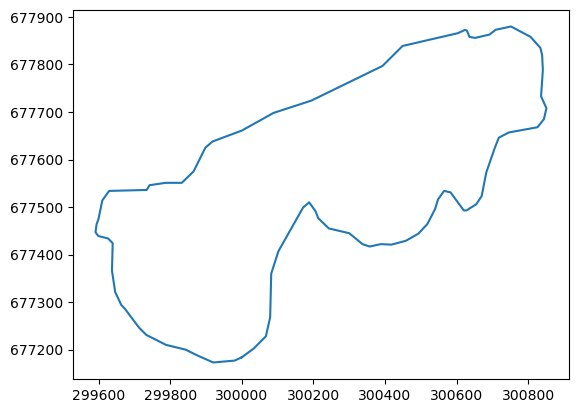

In [11]:
with fiona.open("otherWaterBodies/linlithgow.shp",
                "r") as shapefile:
    
    shapes = [transform.transform_geom('EPSG:27700', 'EPSG:32630',
                                       feature["geometry"]) for feature in shapefile]
    
    
    sf = shp.Reader("otherWaterBodies/linlithgow.shp")

    plt.figure()
    x = [i[0] for i in sf.shapeRecords()[0].shape.points[:]]
    y = [i[1] for i in sf.shapeRecords()[0].shape.points[:]]
    plt.plot(x,y)

    plt.show()
    
    
# shapes = [shapes[10], shapes[28]] # indices of lhs and rhs of loch

In [68]:
glob.glob('otherWaterBodies/shapefiles/*.shp')

['otherWaterBodies/shapefiles/gartmornDam.shp',
 'otherWaterBodies/shapefiles/woodburnReservoir.shp',
 'otherWaterBodies/shapefiles/beecraigsLoch.shp',
 'otherWaterBodies/shapefiles/allochDam.shp',
 'otherWaterBodies/shapefiles/north_third.shp',
 'otherWaterBodies/shapefiles/linlithgow.shp',
 'otherWaterBodies/shapefiles/loch_fitty.shp']

otherWaterBodies/shapefiles/gartmornDam.shp
shapefile Reader
    3 shapes (type 'POLYGON')
    3 records (8 fields)


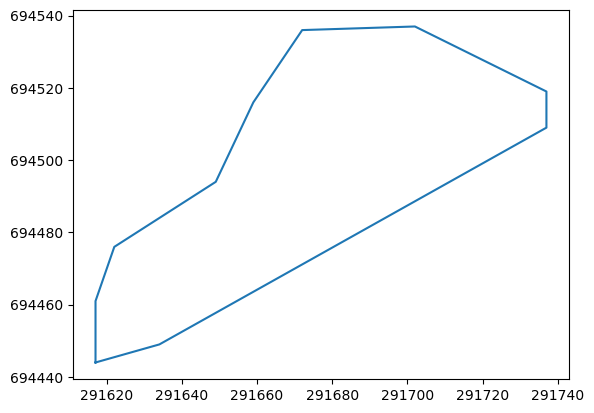

otherWaterBodies/shapefiles/woodburnReservoir.shp
shapefile Reader
    1 shapes (type 'POLYGON')
    1 records (8 fields)


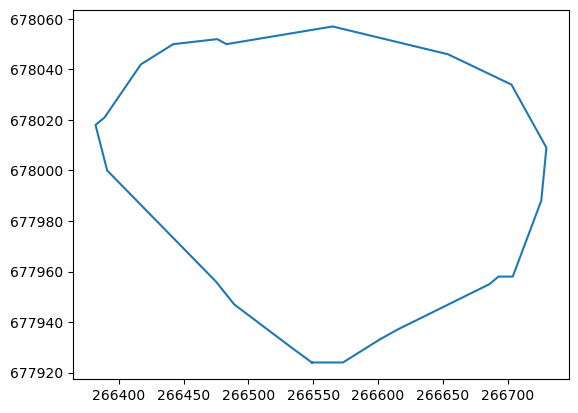

otherWaterBodies/shapefiles/lochfitty.shp
shapefile Reader
    2 shapes (type 'POLYGON')
    2 records (8 fields)


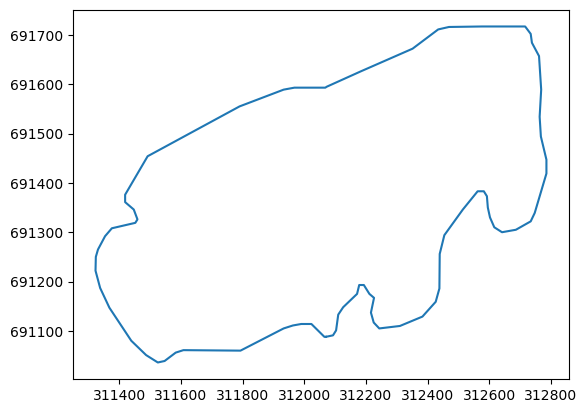

otherWaterBodies/shapefiles/beecraigsLoch.shp
shapefile Reader
    1 shapes (type 'POLYGON')
    1 records (8 fields)


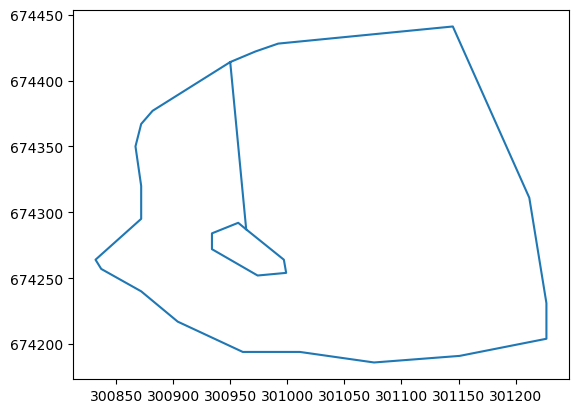

otherWaterBodies/shapefiles/allochDam.shp
shapefile Reader
    1 shapes (type 'POLYGON')
    1 records (8 fields)


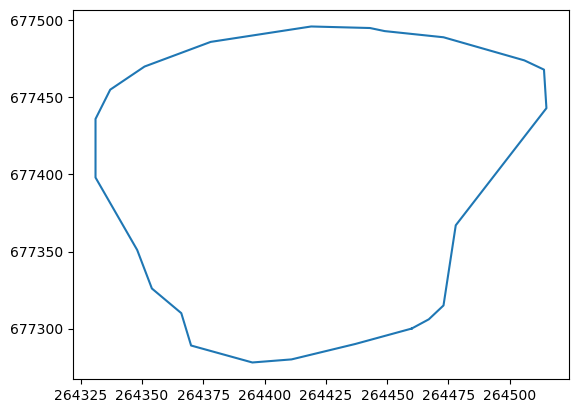

otherWaterBodies/shapefiles/north_third.shp
shapefile Reader
    1 shapes (type 'POLYGON')
    1 records (8 fields)


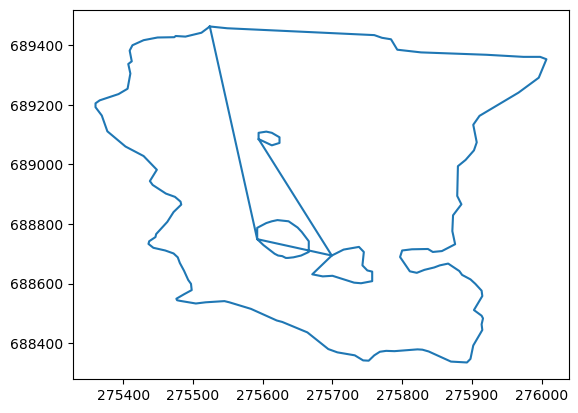

otherWaterBodies/shapefiles/linlithgow.shp
shapefile Reader
    1 shapes (type 'POLYGON')
    1 records (8 fields)


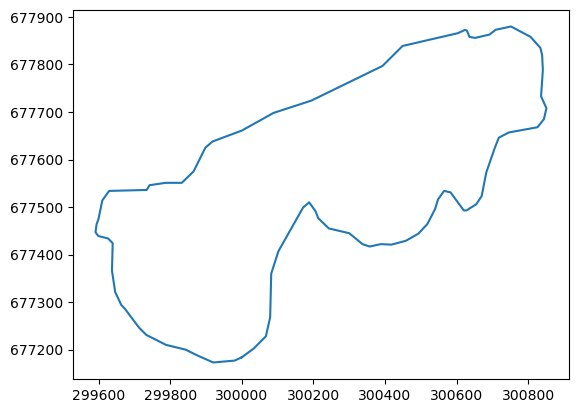

In [87]:
for shpf in glob.glob('otherWaterBodies/shapefiles/*.shp'):
    print(shpf)
    with fiona.open(shpf,
                "r") as shapefile:
    
        shapes = [transform.transform_geom('EPSG:27700', 'EPSG:32630',
                                           feature["geometry"]) for feature in shapefile]


        sf = shp.Reader(shpf)
        
        print(sf)

        plt.figure()
        x = [i[0] for i in sf.shapeRecords()[0].shape.points[:]]
        y = [i[1] for i in sf.shapeRecords()[0].shape.points[:]]
        plt.plot(x,y)

        plt.show()
        
        

In [13]:
shapes[0]

In [75]:
glob.glob('otherWaterBodies/Planet_data/acolite_output_L2W_rhos/*/')

['otherWaterBodies/Planet_data/acolite_output_L2W_rhos/woodburn/',
 'otherWaterBodies/Planet_data/acolite_output_L2W_rhos/fitty/',
 'otherWaterBodies/Planet_data/acolite_output_L2W_rhos/north_third/',
 'otherWaterBodies/Planet_data/acolite_output_L2W_rhos/alloch/',
 'otherWaterBodies/Planet_data/acolite_output_L2W_rhos/beecraigs/',
 'otherWaterBodies/Planet_data/acolite_output_L2W_rhos/linlithgow/',
 'otherWaterBodies/Planet_data/acolite_output_L2W_rhos/gartmorn/']

In [98]:
file[-43:-3] 

'PlanetScope_24c9_2024_01_17_10_39_48_L2W'

In [118]:
dirs = glob.glob('otherWaterBodies/Planet_data/acolite_output_L2W_rhos/*/')

lochs = [dirr[53:-1] for dirr in dirs]

shpfs = glob.glob('otherWaterBodies/shapefiles/*.shp')

for loch in lochs:
    for shpf in shpfs:
        if loch in shpf:
            with fiona.open(shpf, "r") as shapefile:
                shapes = [transform.transform_geom('EPSG:27700', 'EPSG:32630',
                                           feature["geometry"]) for feature in shapefile]
                
    planet_L2W = []
    for i, file in enumerate(glob.glob("otherWaterBodies/Planet_data/acolite_output_L2W_rhos/"\
                                       + loch + "/*L2R.nc")):
        print(i, file)
        planet_L2W.append(file)
        xds = xarray.open_dataset(file)
        xds.rio.write_crs("epsg:32630", inplace=True)
        # do some chl-a calcs
        # can obviously do any math operation I want
        # can probably use my existing algorithm code if the bands are named similarly

        # this is a hacky way of ensuring the thing we put into xds is the right format
        a = xds['rhos_666'].copy()
        a.data = OC3_linear_SD(xds, **SD_OC3_ac_lin_coeff)
        xds['chla_OC3_tuned_SD'] = a
        # make sure it is named properly
        xds['chla_OC3_tuned_SD'].attrs['parameter'] = 'chla_OC3_tuned_SD'

        a = xds['rhos_666'].copy()
        a.data = RBD_tuned_SD(xds)
        xds['chla_RBD_tuned_SD'] = a
        # make sure it is named properly
        xds['chla_RBD_tuned_SD'].attrs['parameter'] = 'chla_RBD_tuned_SD'

        # IMPORTANT
        # change long variable names as these are used when we convert to raster as band names
        for var in list(xds.data_vars):
            try:
                xds[var].attrs['long_name'] = xds[var].attrs['parameter']
            except KeyError:
                pass

        xds.rio.to_raster('otherWaterBodies/map_stuff/rasters/planet/temp.tif')
        # open raster and mask

        with rasterio.open('otherWaterBodies/map_stuff/rasters/planet/temp.tif') as src:
            out_image, out_transform = rasterio.mask.mask(src, shapes, crop=False,
                                                          nodata=np.nan, all_touched=False)
            out_meta = src.meta
            print(src.meta)
            out_desc = src.descriptions

        # write masked raster data to a new raster file
        fname = 'otherWaterBodies/map_stuff/rasters/planet/' + loch + '/' + file[-43:-3] + '.tif'

        out_meta.update({"driver": "GTiff",
                         "transform": out_transform})

        with rasterio.open(fname, "w", **out_meta) as dest:
            dest.write(out_image)
            dest.descriptions = out_desc
                


0 otherWaterBodies/Planet_data/acolite_output_L2W_rhos/castlehill/PlanetScope_2438_2023_09_08_11_10_06_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 338, 'height': 492, 'count': 20, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 461208.0,
       0.0, -3.0, 6230775.0)}
1 otherWaterBodies/Planet_data/acolite_output_L2W_rhos/castlehill/PlanetScope_2448_2023_09_07_10_30_37_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 338, 'height': 492, 'count': 20, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 461208.0,
       0.0, -3.0, 6230775.0)}
2 otherWaterBodies/Planet_data/acolite_output_L2W_rhos/castlehill/PlanetScope_2463_2023_01_26_10_23_03_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 338, 'height': 492, 'count': 20, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 461208.0,
       0.0, -3.0, 6230775.0)}
3 otherWaterBodies/Planet_data/acolite_output_L2W_rhos/castlehill/PlanetScope_2

/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85183/1815374256.py:45: RuntimeWarning: invalid value encountered in log10
  X = np.log10(np.array(np.max([df[Rrs_444],


{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 532, 'height': 292, 'count': 20, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 473328.0,
       0.0, -3.0, 6218544.0)}
7 otherWaterBodies/Planet_data/acolite_output_L2W_rhos/fitty/PlanetScope_24cc_2023_08_11_10_28_54_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 532, 'height': 292, 'count': 20, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 473328.0,
       0.0, -3.0, 6218544.0)}
8 otherWaterBodies/Planet_data/acolite_output_L2W_rhos/fitty/PlanetScope_2488_2024_01_17_11_14_49_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 532, 'height': 292, 'count': 20, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 473328.0,
       0.0, -3.0, 6218544.0)}
9 otherWaterBodies/Planet_data/acolite_output_L2W_rhos/fitty/PlanetScope_247e_2023_01_26_10_59_44_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 532, 'height': 292, 'count': 

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 473, 'height': 286, 'count': 20, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 461832.0,
       0.0, -3.0, 6204474.0)}
1 otherWaterBodies/Planet_data/acolite_output_L2W_rhos/linlithgow/PlanetScope_249a_2023_01_25_11_02_41_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 473, 'height': 286, 'count': 20, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 461832.0,
       0.0, -3.0, 6204474.0)}
2 otherWaterBodies/Planet_data/acolite_output_L2W_rhos/linlithgow/PlanetScope_24cc_2023_08_11_10_28_56_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 473, 'height': 286, 'count': 20, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 461832.0,
       0.0, -3.0, 6204474.0)}
3 otherWaterBodies/Planet_data/acolite_output_L2W_rhos/linlithgow/PlanetScope_24bf_2023_03_07_10_28_51_L2R.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 473, 'height':

In [23]:
# run the routine for all planet files

dirs = 

planet_L2W = []
for i, file in enumerate(glob.glob("otherWaterBodies/Planet_data/acolite_output_L2W_rhos_linlithgow/*L2W.nc")):
    print(i, file)
    planet_L2W.append(file)
    xds = xarray.open_dataset(file)
    xds.rio.write_crs("epsg:32630", inplace=True)
    # do some chl-a calcs
    # can obviously do any math operation I want
    # can probably use my existing algorithm code if the bands are named similarly

    # this is a hacky way of ensuring the thing we put into xds is the right format
    a = xds['Rrs_666'].copy()
    a.data = OC3_linear_SD(xds, **SD_OC3_ac_lin_coeff)
    xds['chla_OC3_tuned_SD'] = a
    # make sure it is named properly
    xds['chla_OC3_tuned_SD'].attrs['parameter'] = 'chla_OC3_tuned_SD'

    a = xds['Rrs_666'].copy()
    a.data = RBD_tuned_SD(xds)
    xds['chla_RBD_tuned_SD'] = a
    # make sure it is named properly
    xds['chla_RBD_tuned_SD'].attrs['parameter'] = 'chla_RBD_tuned_SD'

    # IMPORTANT
    # change long variable names as these are used when we convert to raster as band names
    for var in list(xds.data_vars):
        try:
            xds[var].attrs['long_name'] = xds[var].attrs['parameter']
        except KeyError:
            pass

    xds.rio.to_raster('otherWaterBodies/map_stuff/rasters/planet/temp.tif')
    # open raster and mask

    with rasterio.open('otherWaterBodies/map_stuff/rasters/planet/temp.tif') as src:
        out_image, out_transform = rasterio.mask.mask(src, shapes, crop=False,
                                                      nodata=np.nan, all_touched=False)
        out_meta = src.meta
        print(src.meta)
        out_desc = src.descriptions
        
    # write masked raster data to a new raster file
    fname = 'otherWaterBodies/map_stuff/rasters/planet/' + file[64:-3] + '.tif'

    out_meta.update({"driver": "GTiff",
                     "transform": out_transform})

    with rasterio.open(fname, "w", **out_meta) as dest:
        dest.write(out_image)
        dest.descriptions = out_desc

0 otherWaterBodies/Planet_data/acolite_output_L2W_rhos_linlithgow/PlanetScope_2482_2023_08_07_11_05_37_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 473, 'height': 286, 'count': 29, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 461832.0,
       0.0, -3.0, 6204474.0)}
1 otherWaterBodies/Planet_data/acolite_output_L2W_rhos_linlithgow/PlanetScope_24cc_2023_08_11_10_28_56_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 473, 'height': 286, 'count': 29, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 461832.0,
       0.0, -3.0, 6204474.0)}
2 otherWaterBodies/Planet_data/acolite_output_L2W_rhos_linlithgow/PlanetScope_24bf_2023_03_07_10_28_51_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 473, 'height': 286, 'count': 29, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 461832.0,
       0.0, -3.0, 6204474.0)}
3 otherWaterBodies/Planet_data/acolite_output_L2W_rhos_linlithgow/PlanetScope_2

In [43]:
files = glob.glob('otherWaterBodies/map_stuff/rasters/planet/*L2W.tif')

In [116]:
lochs

['woodburn',
 'fitty',
 'north_third',
 'alloch',
 'beecraigs',
 'linlithgow',
 'gartmorn']

In [121]:
lochs

['castlehill',
 'woodburn',
 'fitty',
 'north_third',
 'alloch',
 'beecraigs',
 'linlithgow',
 'gartmorn']

In [173]:
winter = {'castlehill':'2485_2023_01_26',
          'fitty':'249a_2023_01_25',
          'beecraigs':'24a5_2023_01_26',
          'linlithgow':'249a_2023_01_25',
          'gartmorn':'249a_2023_01_25'
          }
satellite_blooms = {'castlehill':'2438_2023_09_08',
                    'fitty':'24df_2024_07_31',
                    'beecraigs':'24ab_2023_10_23',
                    'linlithgow':'2482_2023_08_07',
                    'gartmorn':'2420_2023_08_07'
                   }
BA_reports = {'castlehill':'2023-09-10',
              'fitty':'2024-07-31',
              'beecraigs':'2023-10-28',
              'linlithgow':'2023-08-10',
              'gartmorn':'2023-08-08'}

nice_loch_names = {'castlehill':'Castlehill Reservoir',
              'fitty':'Loch Fitty',
              'beecraigs':'Beecraigs Loch',
              'linlithgow':'Linlithgow Loch',
              'gartmorn':'Gartmorn Dam'}

In [161]:
def planet_name_to_date(name):
    return(name[5:9] + '-' + name[10:12] + '-' + name[13:])

planet_name_to_date('2420_2023_08_07')

'2023-08-07'

In [165]:
def open_image_local(path_to_image):
    image = Image.open(path_to_image) # Open the image
    image_array = np.array(image) # Convert to a numpy array
    return image_array # Output

# Open the image from my computer
northArrow = open_image_local('map_stuff/north_arrow2.png')

<>:78: SyntaxWarning: invalid escape sequence '\m'
<>:78: SyntaxWarning: invalid escape sequence '\m'
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85183/266663436.py:78: SyntaxWarning: invalid escape sequence '\m'
  fig.colorbar(c, cax=cbar_ax, label='Chl-a ($\mu g \: L^{-1}$)')
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85183/266663436.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.0, 0.0, 0.8, 1]) # rect: tuple (left, bottom, right, top), default: (0, 0, 1, 1)


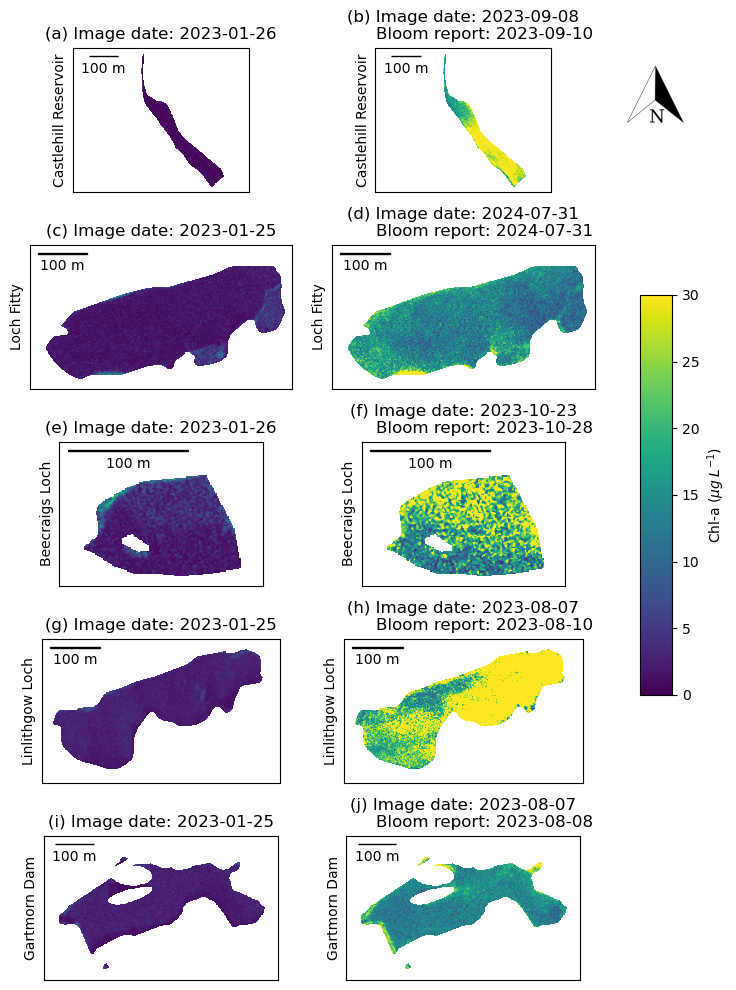

In [213]:
fig, axs = plt.subplots(len(BA_reports), 2, figsize=(8, 10))

letters_left = ['(a)', '(c)', '(e)', '(g)', '(i)']
letters_right = ['(b)', '(d)', '(f)', '(h)', '(j)']


for i, loch in enumerate(BA_reports.keys()):
    
    winter_file = glob.glob('otherWaterBodies/map_stuff/rasters/planet/' \
                            + loch +  '/*' + winter[loch] + '*L2R.tif')
    bloom_file = glob.glob('otherWaterBodies/map_stuff/rasters/planet/' \
                            + loch +  '/*' + satellite_blooms[loch] + '*L2R.tif')
    
    with rasterio.open(winter_file[0]) as src:
            # use imshow so that we have something to map the colorbar to
            c = axs[i, 0].imshow(src.read(19), 
#                                      cmap='YlGnBu_r', 
                                     vmin=0, 
                                     vmax=30,
                         )
    axs[i, 0].set_title(letters_left[i] + ' Image date: ' + planet_name_to_date(winter[loch]))
    
    axs[i, 0].set_ylabel(nice_loch_names[loch])
    axs[i, 1].set_ylabel(nice_loch_names[loch])
            
    with rasterio.open(bloom_file[0]) as src:
            # use imshow so that we have something to map the colorbar to
            c = axs[i, 1].imshow(src.read(19), 
#                                      cmap='YlGnBu_r', 
                                     vmin=0, 
                                     vmax=30,
                         )
            
    axs[i, 1].set_title(letters_right[i] + ' Image date: ' + planet_name_to_date(satellite_blooms[loch]) +\
                        '\n        Bloom report: ' + BA_reports[loch] + '')

axs[0, 0].set_xlim(-200, 400)
axs[0, 1].set_xlim(-200, 400)

axs[2, 0].set_ylim(100, -20)
axs[2, 1].set_ylim(100, -20)


for ax in axs.flatten():
    ax.tick_params(axis='x',          # changes apply to the x-axis
                   which='both',      # both major and minor ticks are affected
                   bottom=False,      # ticks along the bottom edge are off
                   top=False,         # ticks along the top edge are off
                   labelbottom=False) # labels along the bottom edge are off

    ax.tick_params(axis='y',          # changes apply to the x-axis
                   which='both',      # both major and minor ticks are affected
                   left=False,      # ticks along the bottom edge are off
                   right=False,         # ticks along the top edge are off
                   labelleft=False) # labels along the bottom edge are off
    
    scalebar = AnchoredSizeBar(ax.transData,
                                   100, '100 m', 'upper left', 
                                   pad=0.5,
                                   sep=4,
                                   color='black',
                                   frameon=False,
                                   size_vertical=1,
                                   #fontproperties=fontprops
                                  )
    
    ax.add_artist(scalebar)
    
    
arrow_ax = fig.add_axes([0.78, 0.8, 0.1, 0.2]) # (left, bottom, width, height)
arrow_ax.axis('off')

arrow_ax.imshow(northArrow,
                cmap=matplotlib.colors.ListedColormap(['black', 'none'])
)

cbar_ax = fig.add_axes([0.81, 0.3, 0.04, 0.4]) # (left, bottom, width, height)
fig.colorbar(c, cax=cbar_ax, label='Chl-a ($\mu g \: L^{-1}$)')
fig.tight_layout(rect=[0.0, 0.0, 0.8, 1]) # rect: tuple (left, bottom, right, top), default: (0, 0, 1, 1)


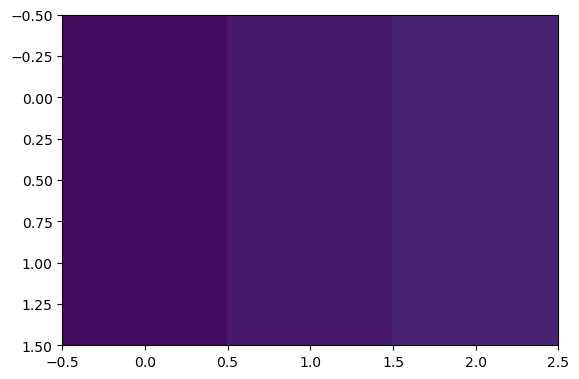

<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:64: SyntaxWarning: invalid escape sequence '\m'
<>:151: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:64: SyntaxWarning: invalid escape sequence '\m'
<>:151: SyntaxWarning: invalid escape sequence '\m'
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85183/589445941.py:35: SyntaxWarning: invalid escape sequence '\m'
  axs[i, 0].text(text_locs[i], 0.02, 'M = {:.0f} $\mu g \: L^{{-1}}$'.format(med) ,
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85183/589445941.py:64: SyntaxWarning: invalid escape sequence '\m'
  axs[i, 1].text(text_locs[i], 0.02, 'M = {:.0f} $\mu g \: L^{{-1}}$'.format(med) ,
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85183/589445941.py:151: SyntaxWarning: invalid escape sequence '\m'
  fig.colorbar(c, cax=cbar_ax, label='Chl-a ($\mu g \: L^{-1}$)')
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85183/589445941.py:1

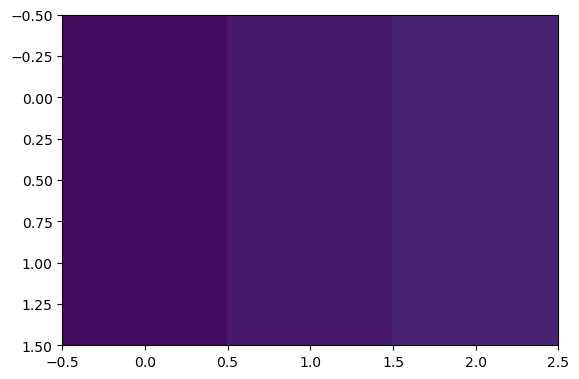

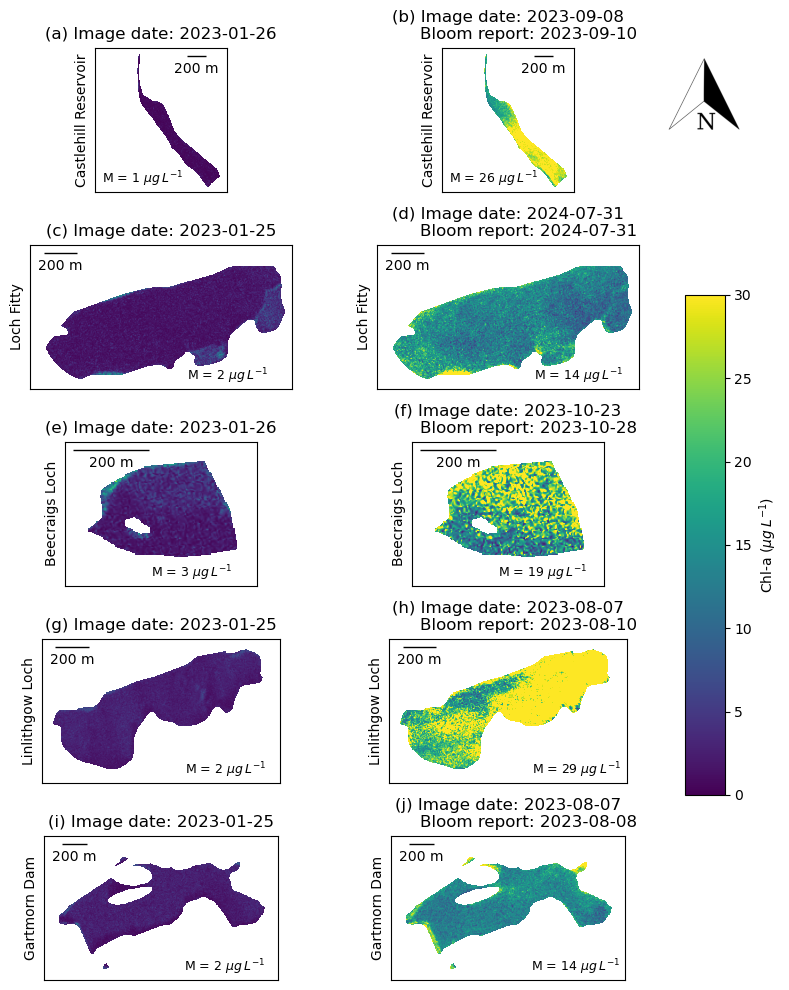

In [220]:
c = plt.imshow(np.array([[1, 2, 3], [1, 2, 3]]), vmin=0, vmax=30)
fig, axs = plt.subplots(len(BA_reports), 2, figsize=(10, 10))

letters_left = ['(a)', '(c)', '(e)', '(g)', '(i)']
letters_right = ['(b)', '(d)', '(f)', '(h)', '(j)']

text_locs = [0.05, 0.6, 0.45, 0.6, 0.6]

for i, loch in enumerate(BA_reports.keys()):
    
    winter_file = glob.glob('otherWaterBodies/map_stuff/rasters/planet/' \
                            + loch +  '/*' + winter[loch] + '*L2R.tif')
    bloom_file = glob.glob('otherWaterBodies/map_stuff/rasters/planet/' \
                            + loch +  '/*' + satellite_blooms[loch] + '*L2R.tif')
    
    with rasterio.open(winter_file[0]) as src:
            # use imshow so that we have something to map the colorbar to
#         c = axs[0, 0].imshow(src.read(19), 
# #                                      cmap='YlGnBu_r', 
#                                  vmin=0, 
#                                  vmax=30,
#                      )
        show(src.read(19), 
#                                      cmap='YlGnBu_r', 
                                     vmin=0, 
                                     vmax=30,
                 transform=src.transform,adjust=True,
                 ax=axs[i, 0]
                         )
        
        rast = src.read(19)
        avg = np.nanmean(rast[:, :])
        med = np.nanmedian(rast[:, :])
        
    axs[i, 0].text(text_locs[i], 0.02, 'M = {:.0f} $\mu g \: L^{{-1}}$'.format(med) ,
                transform=axs[i, 0].transAxes, fontsize=9,
                verticalalignment='bottom', #bbox=props
                  )
        
    axs[i, 0].set_title(letters_left[i] + ' Image date: ' + planet_name_to_date(winter[loch]))
    
    axs[i, 0].set_ylabel(nice_loch_names[loch])
    axs[i, 1].set_ylabel(nice_loch_names[loch])

            
    with rasterio.open(bloom_file[0]) as src:
            # use imshow so that we have something to map the colorbar to
#             c = axs[i, 1].imshow(src.read(19), 
# #                                      cmap='YlGnBu_r', 
#                                      vmin=0, 
#                                      vmax=30,
#                          )
        show(src.read(19), 
#                                      cmap='YlGnBu_r', 
                                     vmin=0, 
                                     vmax=30,
                 transform=src.transform,adjust=True,
                 ax=axs[i, 1]
                         )
        rast = src.read(19)
        avg = np.nanmean(rast[:, :])
        med = np.nanmedian(rast[:, :])
        
    axs[i, 1].text(text_locs[i], 0.02, 'M = {:.0f} $\mu g \: L^{{-1}}$'.format(med) ,
                transform=axs[i, 1].transAxes, fontsize=9,
                verticalalignment='bottom', #bbox=props
                  )
            
    axs[i, 1].set_title(letters_right[i] + ' Image date: ' + planet_name_to_date(satellite_blooms[loch]) +\
                        '\n        Bloom report: ' + BA_reports[loch] + '')

# axs[0, 0].set_xlim(-200, 400)
# axs[0, 1].set_xlim(-200, 400)

# axs[2, 0].set_ylim(100, -20)
# axs[2, 1].set_ylim(100, -20)


for i, ax in enumerate(axs.flatten()):
    ax.tick_params(axis='x',          # changes apply to the x-axis
                   which='both',      # both major and minor ticks are affected
                   bottom=False,      # ticks along the bottom edge are off
                   top=False,         # ticks along the top edge are off
                   labelbottom=False) # labels along the bottom edge are off

    ax.tick_params(axis='y',          # changes apply to the x-axis
                   which='both',      # both major and minor ticks are affected
                   left=False,      # ticks along the bottom edge are off
                   right=False,         # ticks along the top edge are off
                   labelleft=False) # labels along the bottom edge are off
    
#     def reproject_coords(src_crs, dst_crs, coords):
#         xs = [c[0] for c in coords]
#         ys = [c[1] for c in coords]
#         xs, ys = fiona.transform.transform(src_crs, dst_crs, xs, ys)
#         return [[x,y] for x,y in zip(xs, ys)]

#     src_crs = 'EPSG:32630'
#     dst_crs = 'EPSG:4326'



#     ax.locator_params(nbins=4)


#     xs = ax.get_xticks()
#     ys = ax.get_yticks()

#     coords = [[x, y] for x, y in zip(xs, ys)]
#     print(coords)
#     new_coords = reproject_coords(src_crs, dst_crs, coords)

#     ax.set_xticklabels([str(round(coord[0], 3)) for coord in new_coords])
#     ax.set_yticklabels([str(round(coord[1], 3)) for coord in new_coords])

#     ax.set_xlabel('Longitude ($\degree$)')
#     ax.set_ylabel('Latitude ($\degree$)')
    
    if i < 2:
        # location of scale bar
        loc = 'upper right'
    else:
        loc = 'upper left'
    scalebar = AnchoredSizeBar(ax.transData,
                               200, '200 m', loc, 
                               pad=0.5,
                               sep=4,
                               color='black',
                               frameon=False,
                               size_vertical=1,
                               #fontproperties=fontprops
                              )
    
    ax.add_artist(scalebar)
    
axs[0, 0].set_xlim([460870.0, 462222.0])
axs[2, 0].set_ylim(6200650.0, 6201030.0)

axs[0, 1].set_xlim([460870.0, 462222.0])
axs[2, 1].set_ylim(6200650.0, 6201030.0)
    
    
arrow_ax = fig.add_axes([0.72, 0.8, 0.1, 0.2]) # (left, bottom, width, height)
arrow_ax.axis('off')

arrow_ax.imshow(northArrow,
                cmap=matplotlib.colors.ListedColormap(['black', 'none'])
)

cbar_ax = fig.add_axes([0.75, 0.2, 0.04, 0.5]) # (left, bottom, width, height)
fig.colorbar(c, cax=cbar_ax, label='Chl-a ($\mu g \: L^{-1}$)')


fig.tight_layout(rect=[0.0, 0.0, 0.8, 1]) # rect: tuple (left, bottom, right, top), default: (0, 0, 1, 1)
plt.savefig('figures_for_paper/otherWaterBodies.svg', dpi=300)


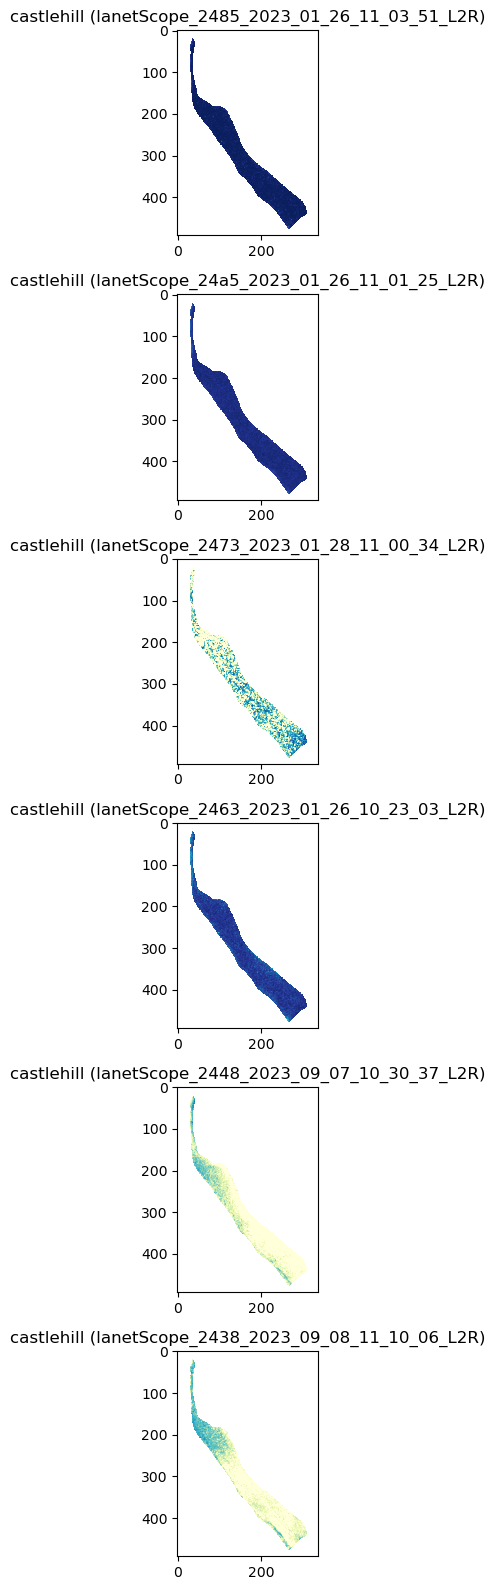

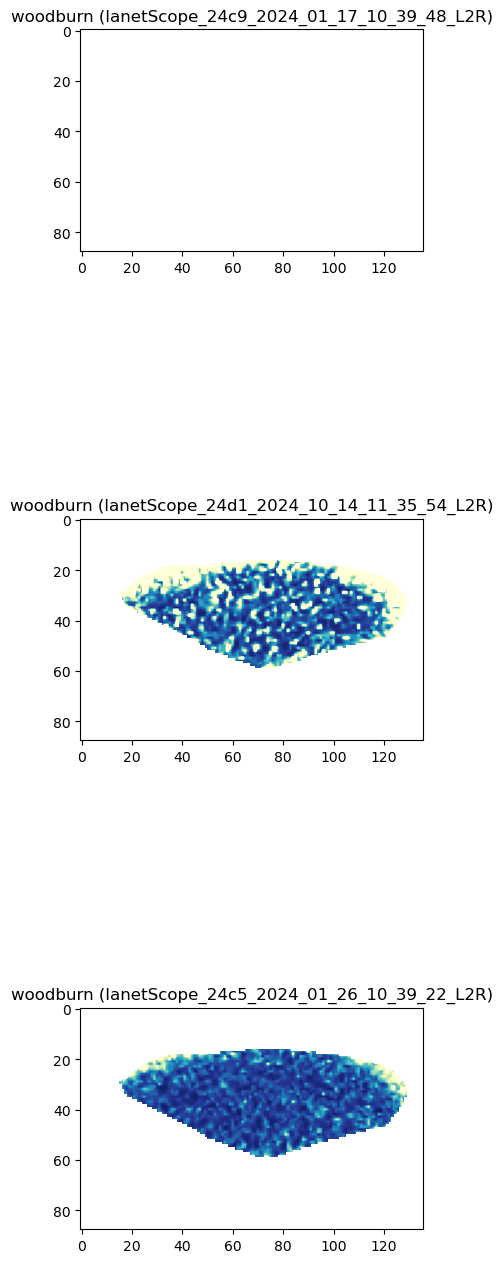

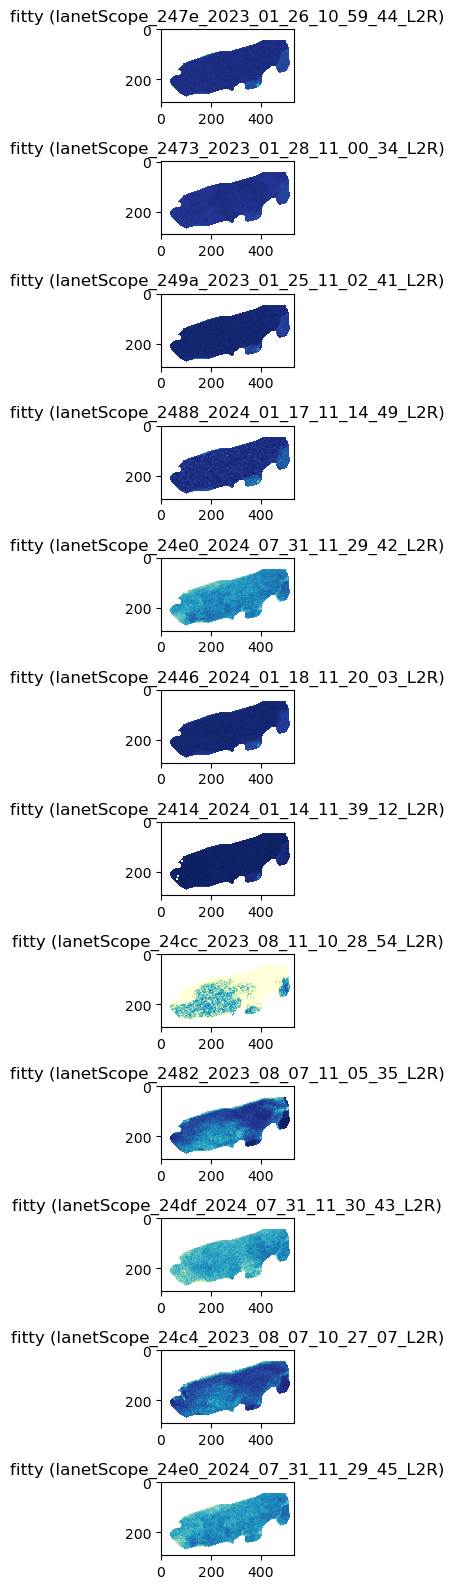

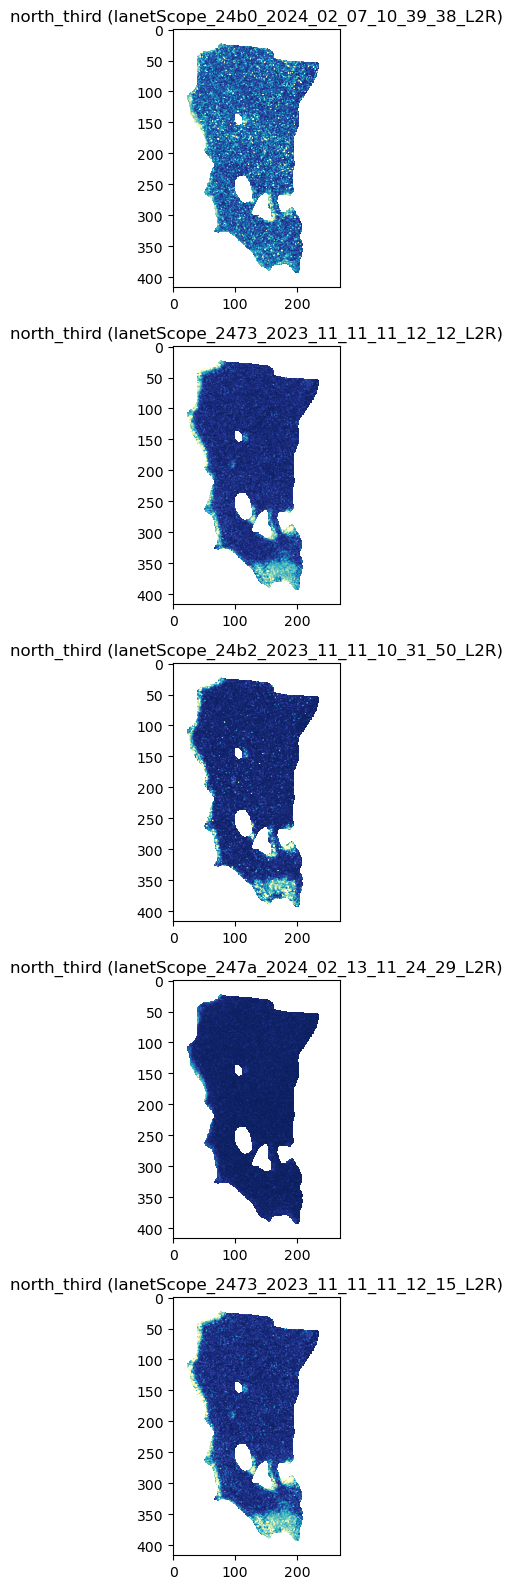

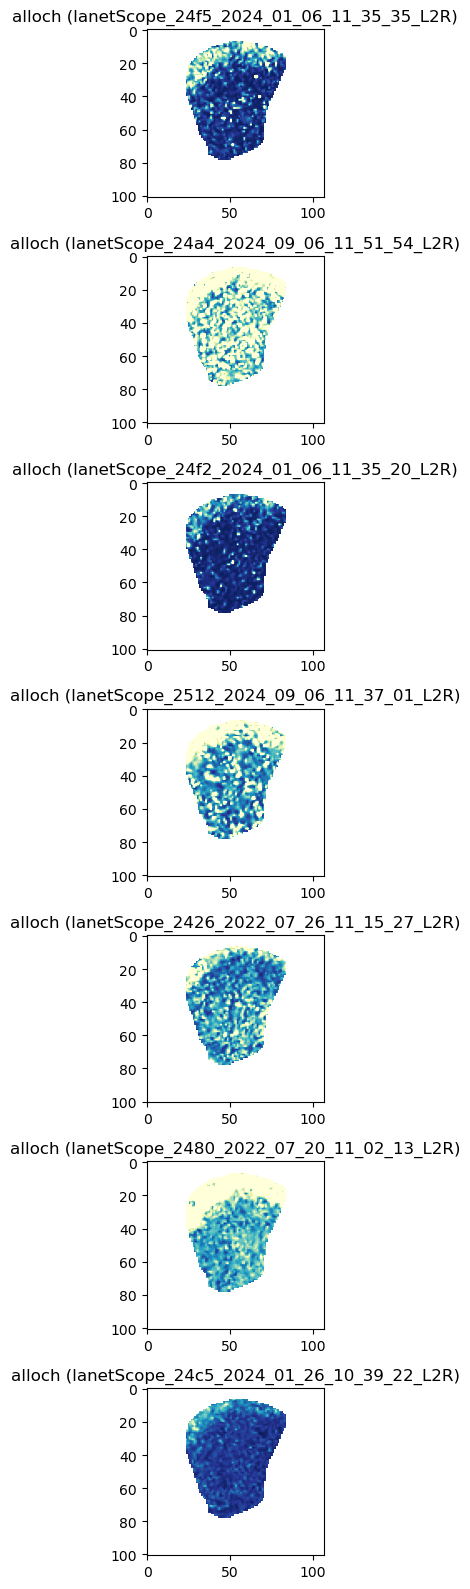

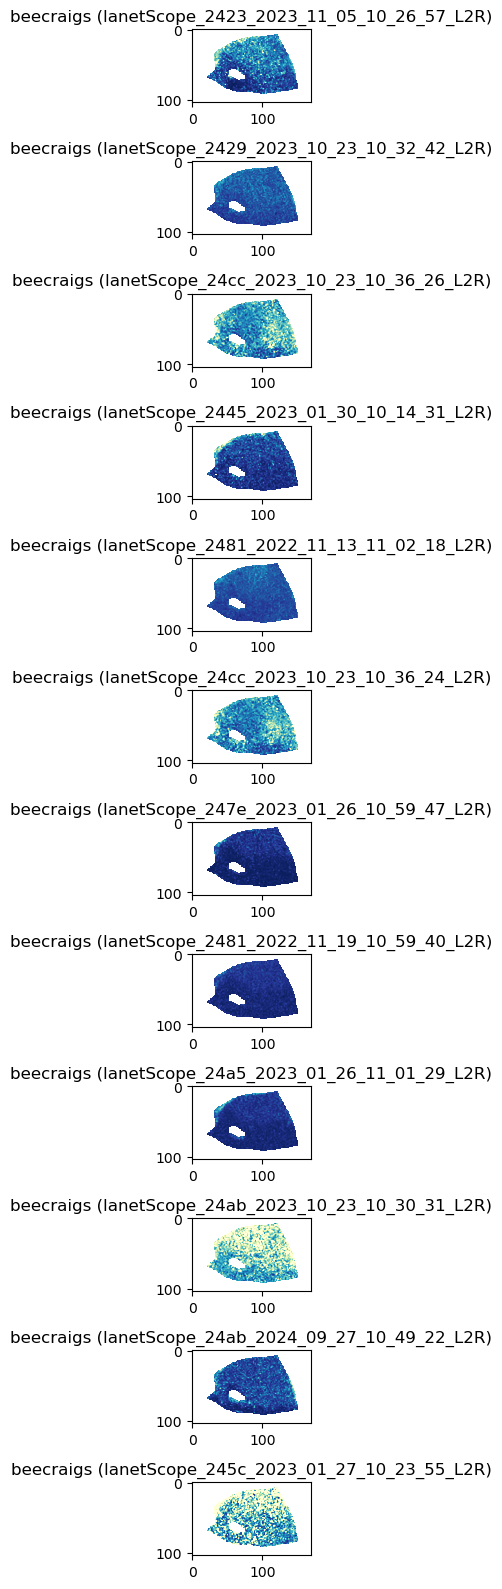

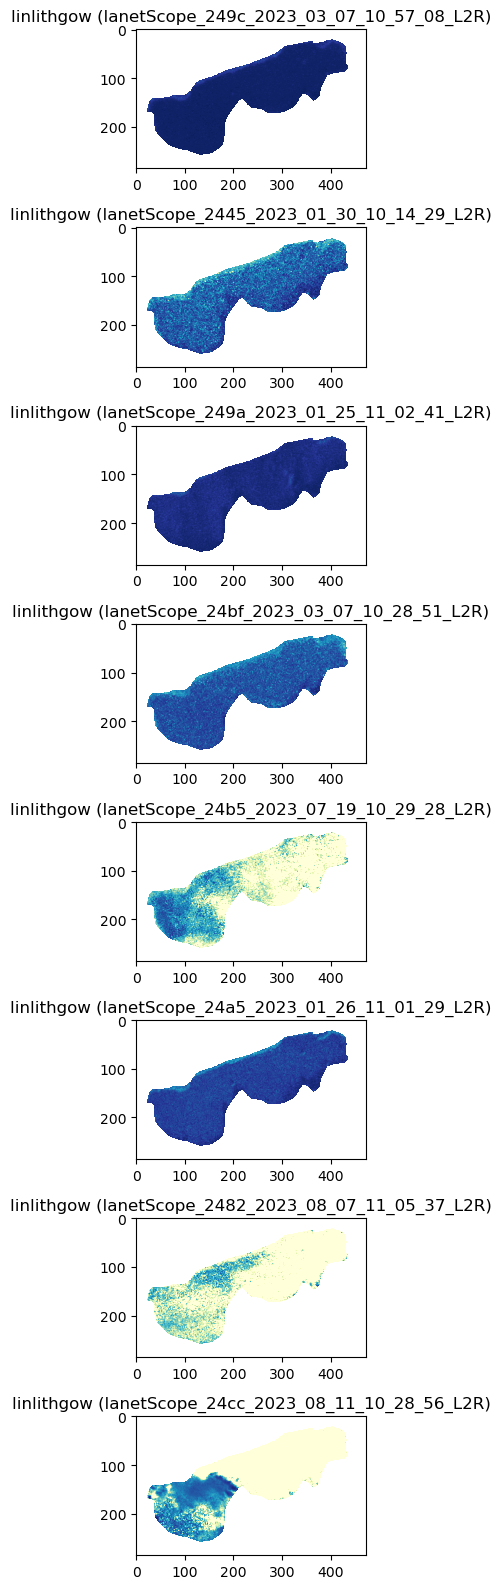

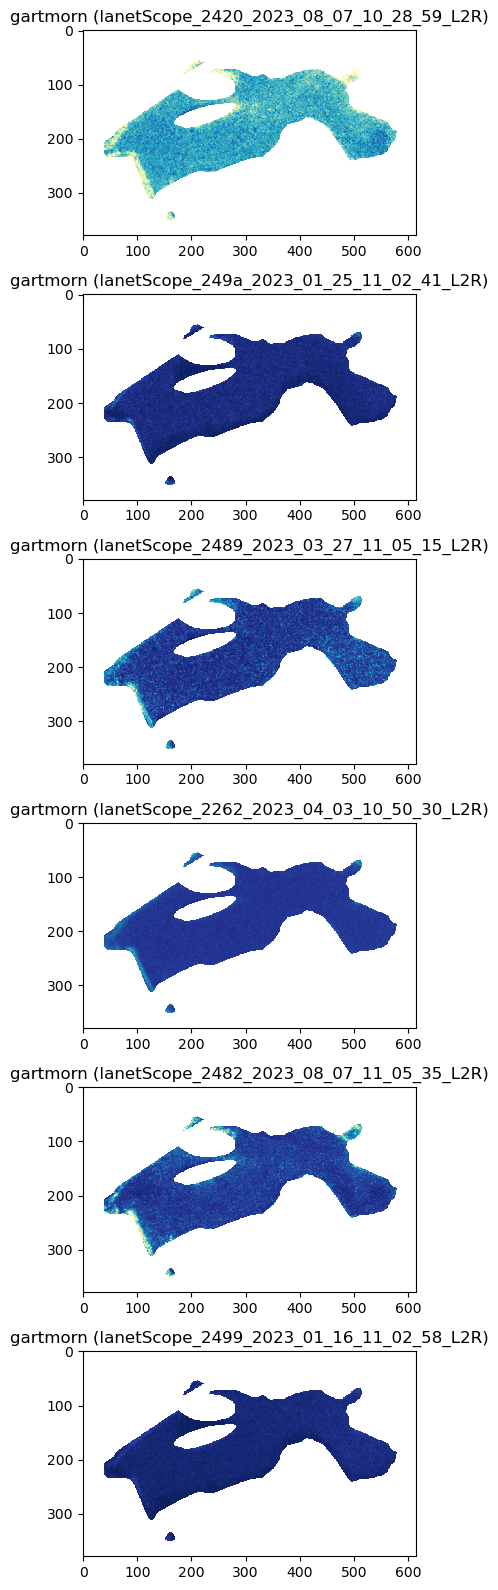

In [125]:
for loch in lochs:
    files = glob.glob('otherWaterBodies/map_stuff/rasters/planet/' + loch +  '/*L2R.tif')

    fig, axs = plt.subplots(len(files), 1, figsize=(4, 16))

    for file, ax in zip(files, axs.flatten()):
        with rasterio.open(file) as src:
            # use imshow so that we have something to map the colorbar to
            c = ax.imshow(src.read(19), 
                                     cmap='YlGnBu_r', 
                                     vmin=0, 
                                     vmax=30,
                         )
        ax.set_title(loch + ' (' + file[-43:-4] + ')')

    plt.tight_layout()
    plt.show()

In [52]:
# should be fairly straight forward to 

'2023_08_07_11_05_37_L2W.'